# Laboratorio 6

## Red bipartita autor video

Repositorio

https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio6

Este notebook presenta la actividad 4 del laboratorio.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

RAIZ = Path.cwd()
if not (RAIZ / "scripts").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

from scripts.analisis_avance import (
    ejecutar_avance,
    graficar_red_completa,
    puentes_observados,
    resumen_componentes,
    resumen_red,
)

resultado = ejecutar_avance()
nodos = resultado["nodos"]
aristas = resultado["aristas"]
red = resultado["red"]
autores = resultado["autores"]
videos_compartidos = resultado["videos_compartidos"]
comentarios = resultado["comentarios"]
pd.set_option("display.max_colwidth", 80)

## 4.1 Construcción de la red

La red es no dirigida y tiene dos tipos de nodos. Un tipo representa autores y el otro representa videos. Los autores se identifican con author_channel_id y los videos con video_id.

Una arista indica que un autor publicó al menos un comentario principal en un video. Su peso es la cantidad de comentarios de ese autor en ese video.

La arista no demuestra amistad, conversación directa, aprobación ni respuesta entre usuarios.

In [2]:
pd.DataFrame({
    "comprobacion": [
        "la red es bipartita",
        "suma de pesos",
        "comentarios originales",
        "aristas únicas autor video",
    ],
    "valor": [
        nx.algorithms.bipartite.is_bipartite(red),
        aristas["peso"].sum(),
        len(comentarios),
        len(aristas),
    ],
})

,comprobacion,valor
0,la red es bipartita,True
1,suma de pesos,406
2,comentarios originales,406
3,aristas únicas autor video,343


## 4.2 Tabla de nodos

La tabla completa se guarda en data/processed/nodos_red_bipartita.csv. Incluye el tipo de nodo, su etiqueta visible, identificadores, actividad y atributos del video cuando corresponden.

In [3]:
display(nodos.groupby("tipo").size().rename("cantidad").reset_index())
display(nodos.head(15))

,tipo,cantidad
0,autor,332
1,video,293


,nodo_id,tipo,etiqueta,handle,author_channel_id,video_id,channel_id,canal,comentarios,videos_comentados,autores_unicos,visualizaciones,categoria
0,autor:UC-HeUTT6_g-VoiWds2a4H-w,autor,@JorgeMunoz-gd9et,/@JorgeMunoz-gd9et,UC-HeUTT6_g-VoiWds2a4H-w,None,None,None,1.0,1.0,NaN,NaN,None
1,autor:UC-Iul5tDYH_oiAMXQH-KaaQ,autor,@AlbertoMancilla-p9h,/@AlbertoMancilla-p9h,UC-Iul5tDYH_oiAMXQH-KaaQ,None,None,None,1.0,1.0,NaN,NaN,None
2,autor:UC-QOpE7GOxlXcHZ8b7HbQKA,autor,@mariaalexander427,/@mariaalexander427,UC-QOpE7GOxlXcHZ8b7HbQKA,None,None,None,2.0,1.0,NaN,NaN,None
3,autor:UC-fiZBS5Gp1eCJd9ucgWnCg,autor,@Tommii.10,/@Tommii.10,UC-fiZBS5Gp1eCJd9ucgWnCg,None,None,None,1.0,1.0,NaN,NaN,None
4,autor:UC-hfX8J5JPJ-dfuakzegMLA,autor,@normaleticiaorozcojuarez2418,/@normaleticiaorozcojuarez2418,UC-hfX8J5JPJ-dfuakzegMLA,None,None,None,1.0,1.0,NaN,NaN,None
5,autor:UC-jS_kA9w-OmpupXDx156Rg,autor,@simoncreyesc7579,/@simoncreyesc7579,UC-jS_kA9w-OmpupXDx156Rg,None,None,None,1.0,1.0,NaN,NaN,None
6,autor:UC-pNP6RMFuLg_-x7Ah_0kEA,autor,@almacatalan2717,/@almacatalan2717,UC-pNP6RMFuLg_-x7Ah_0kEA,None,None,None,1.0,1.0,NaN,NaN,None
7,autor:UC094EFEmMSdwVa8NQjjYBXg,autor,@CelestinoQuej-j7k,/@CelestinoQuej-j7k,UC094EFEmMSdwVa8NQjjYBXg,None,None,None,1.0,1.0,NaN,NaN,None
8,autor:UC0HvfEWozTHbwl_iEmJNvVA,autor,@OttoPalencia-b7r,/@OttoPalencia-b7r,UC0HvfEWozTHbwl_iEmJNvVA,None,None,None,1.0,1.0,NaN,NaN,None
9,autor:UC0RpuMwkDKJYqgKHtsJRuWQ,autor,@sabinamarinaguerra3248,/@sabinamarinaguerra3248,UC0RpuMwkDKJYqgKHtsJRuWQ,None,None,None,1.0,1.0,NaN,NaN,None


## 4.3 Tabla de aristas

La tabla completa se guarda en data/processed/aristas_red_bipartita.csv. Cada fila es una combinación única de autor y video.

In [4]:
aristas.head(20)

,origen,destino,author_channel_id,video_id,peso
0,autor:UC-HeUTT6_g-VoiWds2a4H-w,video:6W4u8sGEnGM,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,autor:UC-Iul5tDYH_oiAMXQH-KaaQ,video:6W4u8sGEnGM,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,autor:UC-QOpE7GOxlXcHZ8b7HbQKA,video:OkXlHx0hx-8,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,autor:UC-fiZBS5Gp1eCJd9ucgWnCg,video:j43HgwYFKfk,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,autor:UC-hfX8J5JPJ-dfuakzegMLA,video:n8iP75gIpmw,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1
5,autor:UC-jS_kA9w-OmpupXDx156Rg,video:n8iP75gIpmw,UC-jS_kA9w-OmpupXDx156Rg,n8iP75gIpmw,1
6,autor:UC-pNP6RMFuLg_-x7Ah_0kEA,video:n8iP75gIpmw,UC-pNP6RMFuLg_-x7Ah_0kEA,n8iP75gIpmw,1
7,autor:UC094EFEmMSdwVa8NQjjYBXg,video:b_Hkrkl3adA,UC094EFEmMSdwVa8NQjjYBXg,b_Hkrkl3adA,1
8,autor:UC0HvfEWozTHbwl_iEmJNvVA,video:6W4u8sGEnGM,UC0HvfEWozTHbwl_iEmJNvVA,6W4u8sGEnGM,1
9,autor:UC0RpuMwkDKJYqgKHtsJRuWQ,video:lj983NWyAQY,UC0RpuMwkDKJYqgKHtsJRuWQ,lj983NWyAQY,1


## 4.4 Visualización de la red completa

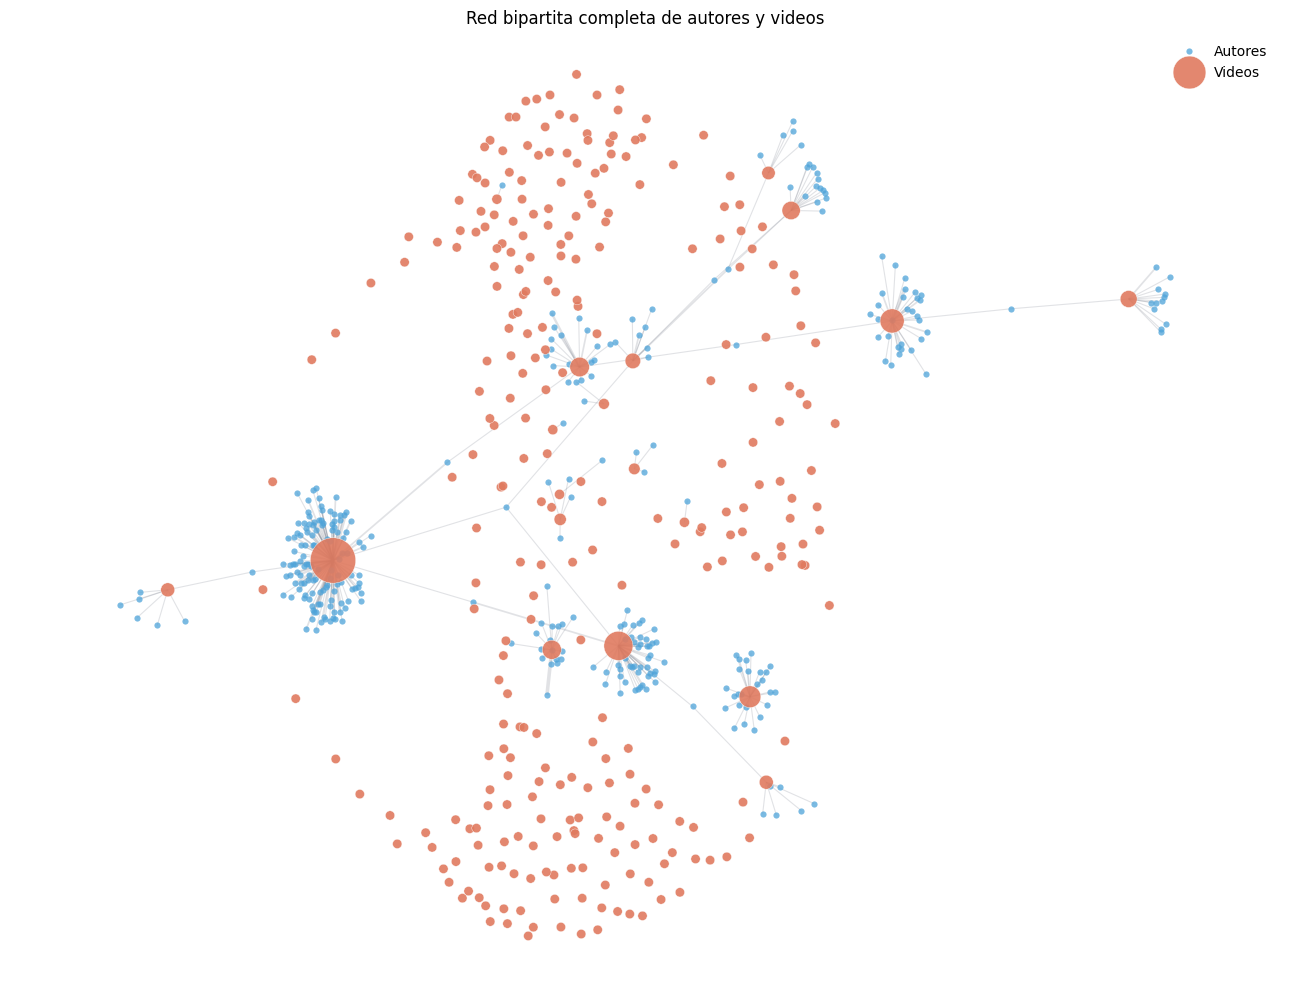

In [5]:
graficar_red_completa(red)
plt.show()

Todos los nodos y todas las aristas se mantienen en la figura. Los autores se muestran en azul y los videos en naranja. Los nodos de video crecen según su grado. La posición solo ayuda a ver la estructura y no representa distancia geográfica ni cercanía social.

## Resumen de la estructura observada

In [6]:
resumen_red(red)

,medida,valor
0,nodos,625.0000
1,autores,332.0000
2,videos,293.0000
3,aristas,343.0000
4,componentes conexas,284.0000
5,nodos en componente mayor,286.0000
6,grado medio,1.0976
7,densidad bipartita,0.0035


La red tiene 625 nodos y 343 aristas. Incluye 332 autores y 293 videos. Hay 284 componentes conectadas. La componente mayor contiene 286 nodos.

### Participantes recurrentes y cruces de audiencia

In [7]:
display(autores.head(15))
display(videos_compartidos.head(15))

,author_channel_id,autor,comentarios,videos,canales,consultas
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,4,3,1,1
276,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,1,2
98,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,3,2,2,2
211,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,2,2
250,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2,2
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2,2
325,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,3,2,1,2
207,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2,1,1
330,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,1,2
241,UCi2KiZq63sRq8Mfbcp-MelQ,@eugeneramirez4405,6,1,1,1


,video_id_1,video_id_2,autores_compartidos
0,ndAZjHqzzT8,yLZS3JiEBg8,2
1,j43HgwYFKfk,n8iP75gIpmw,2
2,PjmxCj-a9Hg,n8iP75gIpmw,1
3,is3Mk5oC19g,j43HgwYFKfk,1
4,06mFNPU0aB8,6W4u8sGEnGM,1
5,j43HgwYFKfk,ndAZjHqzzT8,1
6,n8iP75gIpmw,ndAZjHqzzT8,1
7,b_Hkrkl3adA,n8iP75gIpmw,1
8,WIUZtitfLRw,ndAZjHqzzT8,1
9,WIUZtitfLRw,yLZS3JiEBg8,1


Hay 9 autores que comentaron en más de un video y 4 que aparecen en más de un canal. Estos autores conectan contenidos dentro de la muestra, pero eso no demuestra una relación personal con otros autores.

### Puntos de articulación

In [8]:
puentes_observados(red)

,nodo_id,autor,videos_comentados,punto_de_articulacion
276,autor:UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,True
307,autor:UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,3,True
98,autor:UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,2,True
211,autor:UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,True
250,autor:UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,True
287,autor:UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,True
330,autor:UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,True
207,autor:UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,False
325,autor:UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,2,False
0,autor:UC-HeUTT6_g-VoiWds2a4H-w,@JorgeMunoz-gd9et,1,False


En la tabla mostrada hay 7 autores que son puntos de articulación. Quitarlos aumentaría la fragmentación de la red observada. Esta propiedad depende de la cobertura de comentarios y no debe interpretarse como influencia general en YouTube.

### Componentes principales

In [9]:
resumen_componentes(red, comentarios)

,componente,nodos,autores,videos,comentarios,palabras_frecuentes,sentimiento_principal,porcentaje_sentimiento_principal
0,1,286,276,10,343,"pueblo, dinero, presidente, solo, trabajo",neutral,70.55
1,2,26,25,1,25,"guatemala, ciudad, saludos, todos, viva",neutral,80.00
2,3,19,18,1,25,"you, usa, pais, otros, país",neutral,76.00


Las componentes muestran grupos separados por falta de autores compartidos en los datos. Un grupo separado puede reflejar una audiencia distinta, pero también puede aparecer porque la recolección no incluyó suficientes comentarios. La detección formal de comunidades se presenta en el notebook 03.Resultados_Finales.

## Conclusión del análisis de red

La red confirma que la mayor parte de la participación observada ocurre alrededor de pocos videos y que casi todos los autores aparecen en un solo contenido. Los pocos autores recurrentes ayudan a unir videos o canales. La estructura solo representa coparticipación en los comentarios recolectados.